Trying out Shap : First Iteration Model


In [66]:
import xgboost 
import pickle
import pandas as pd
# import matplotlib
import matplotlib.pyplot as plt

# # Load the model
# with open('xgb_model.pkl', 'rb') as f:
#     model = pickle.load(f)
    
# with open("gridxgb_model.pkl", "wb") as f:
#     model2 = pickle.load(f)
    
# with open("rf_model.pkl", "wb") as f:
#     model2 = pickle.load(f)

In [67]:
import shap

# Create explainer for tree-based models
# explainer = shap.TreeExplainer(model)
# explainer_rf = shap.TreeExplainer(model2)

In [68]:
# Calculate SHAP values for test set
# test_df = pd.read_csv('test.csv')
# X_test = test_df.drop(columns=["TenYearCHD", "stratify"])
# shap_values = explainer.shap_values(X_test)
# # shap_values_rf = explainer_rf.shap_values(X_test)

# # Get expected value (baseline)
# expected_value = explainer.expected_value
# # expected_value_rf = explainer_rf.expected_value 

In [69]:
# Summary plot (global feature importance)
# shap.summary_plot(shap_values, X_test)

# # Beeswarm plot (more detailed)
# shap.summary_plot(shap_values, X_test, plot_type="dot")

# Waterfall plot for single patient (first test patient)
# male_patient = X_test.iloc[70]
# female_patient = male_patient.copy()

# female_patient['male'] = 0

# created_pair = pd.DataFrame([male_patient, female_patient])
# print(male_patient)
# shap_values_pair = explainer.shap_values(created_pair)



# shap.waterfall_plot(shap.Explanation(
#     values=shap_values_pair[0],
#     base_values=expected_value,
#     data=created_pair.iloc[0],
#     feature_names=X_test.columns.tolist()
# ))

# shap.waterfall_plot(shap.Explanation(
#     values=shap_values_pair[1],
#     base_values=expected_value,
#     data=created_pair.iloc[1],
#     feature_names=X_test.columns.tolist()
# ))

# shap.waterfall_plot(shap.Explanation(
#     values=shap_values_rf[28],
#     base_values=expected_value_rf,
#     data=X_test.iloc[28],
#     feature_names=X_test.columns.tolist()
# ))

# shap.waterfall_plot(shap.Explanation(
#     values=shap_values[100],
#     base_values=expected_value,
#     data=X_test.iloc[100],
#     feature_names=X_test.columns.tolist()
# ))

In [74]:
#  SHAP on the cardio_dataset trained baseline model
with open("models/baseline_models/cardio_xgb_baseline_model.pkl", 'rb') as f:
    model_baseline = pickle.load(f)

explainer_baseline = shap.TreeExplainer(model_baseline)

# TUNED MODEL
with open("models/baseline_models/cardio_xgb_tuned_model.pkl", 'rb') as f:
    model_tuned = pickle.load(f)

explainer_tuned = shap.TreeExplainer(model_tuned)

In [75]:
# Calculate SHAP values for test set
test_df_baseline = pd.read_csv('data/test_train_val_sets/cardio_baseline_test.csv')
y_test_baseline = test_df_baseline["cardio"]

X_test_baseline = test_df_baseline.drop(columns=["cardio", "stratify"])
shap_values_baseline = explainer_baseline.shap_values(X_test_baseline)
# shap_values_rf = explainer_rf.shap_values(X_test)

# Get expected value (baseline)
expected_value = explainer_baseline.expected_value

# expected_value_rf = explainer_rf.expected_value 

In [77]:
test_df_tuned = pd.read_csv('data/test_train_val_sets/cardio_baseline_test.csv')
y_test_tuned = test_df_tuned["cardio"]

X_test_tuned = test_df_tuned.drop(columns=["cardio", "stratify"])
shap_values_tuned = explainer_tuned.shap_values(X_test_baseline)
# shap_values_rf = explainer_rf.shap_values(X_test)

# Get expected value (baseline)
expected_value= explainer_tuned.expected_value


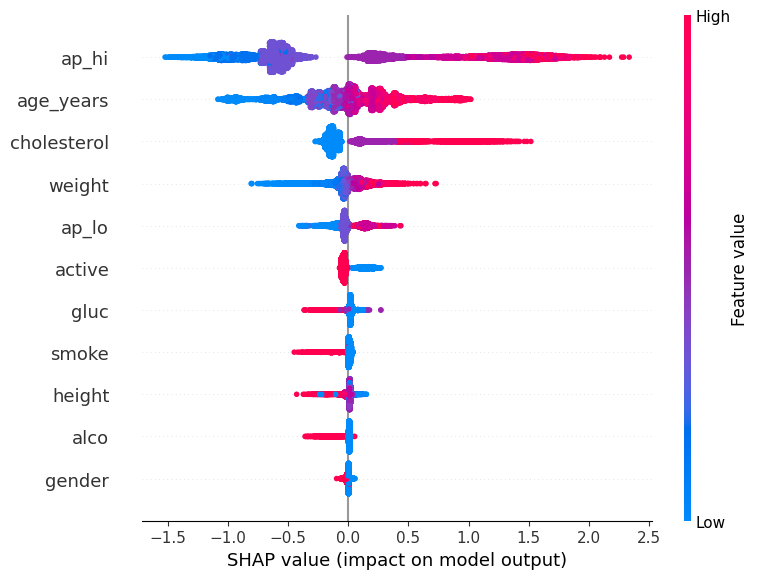

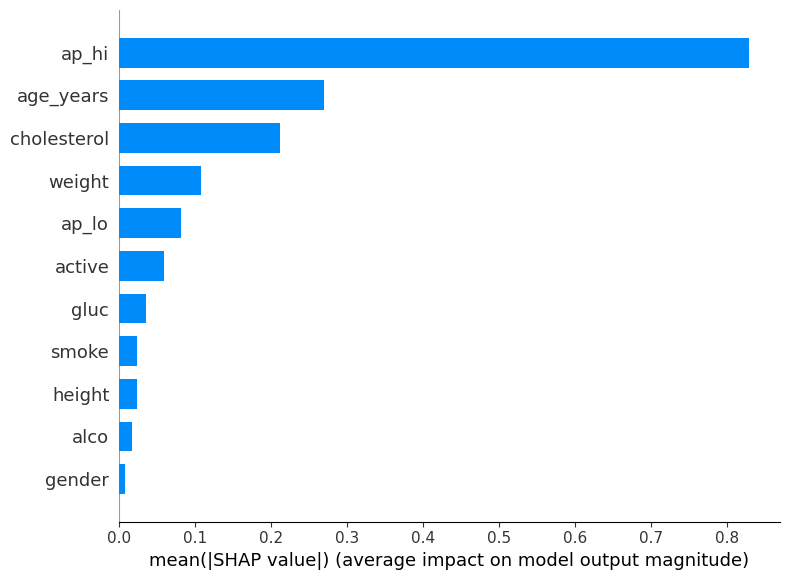

In [ ]:
shap.summary_plot(shap_values_baseline, X_test_baseline, plot_type="dot")
shap.summary_plot(shap_values_baseline, X_test_baseline, plot_type="bar")


shap.summary_plot(shap_values_tuned, X_test_tuned, plot_type="dot")
shap.summary_plot(shap_values_tuned, X_test_tuned, plot_type="bar")

# Sex-Stratified SHAP now

In [ ]:
X_test_female = X_test_baseline[X_test_baseline['gender'] == 0]
X_test_male   = X_test_baseline[X_test_baseline['gender'] == 1]

shap_values_female = explainer_baseline.shap_values(X_test_female)
shap_values_male   = explainer_baseline.shap_values(X_test_male)


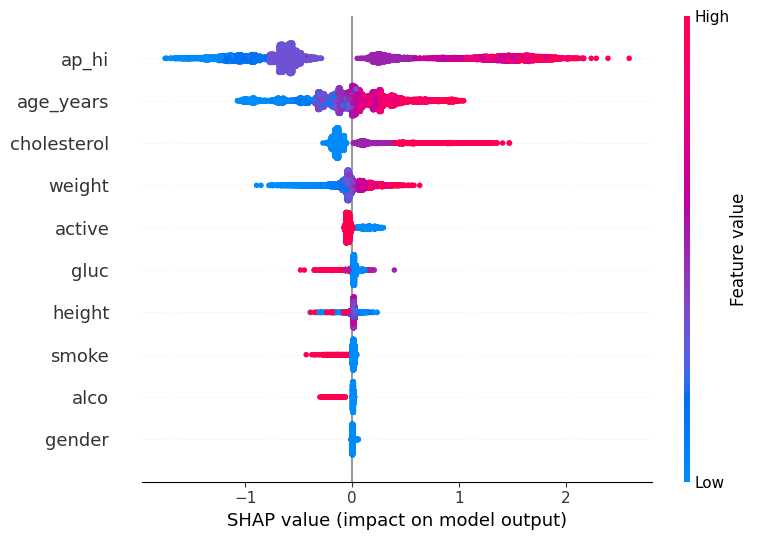

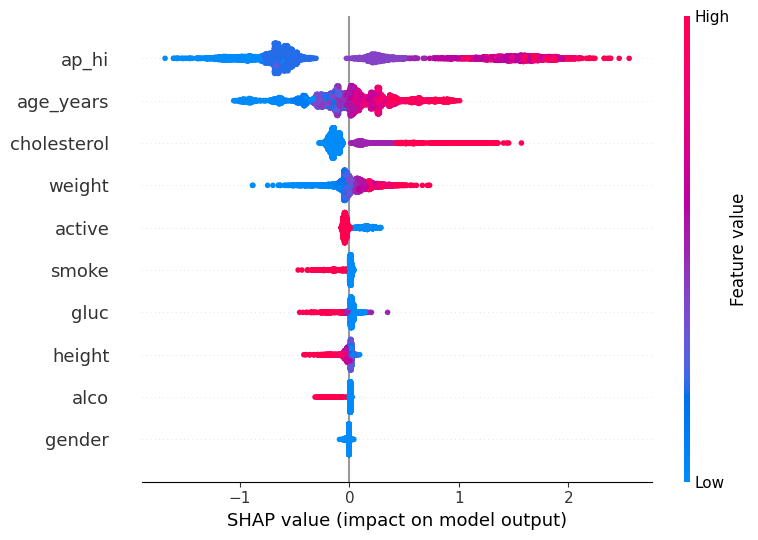

In [ ]:
shap.summary_plot(shap_values_female, X_test_female, plot_type="dot")
shap.summary_plot(shap_values_male, X_test_male, plot_type="dot")

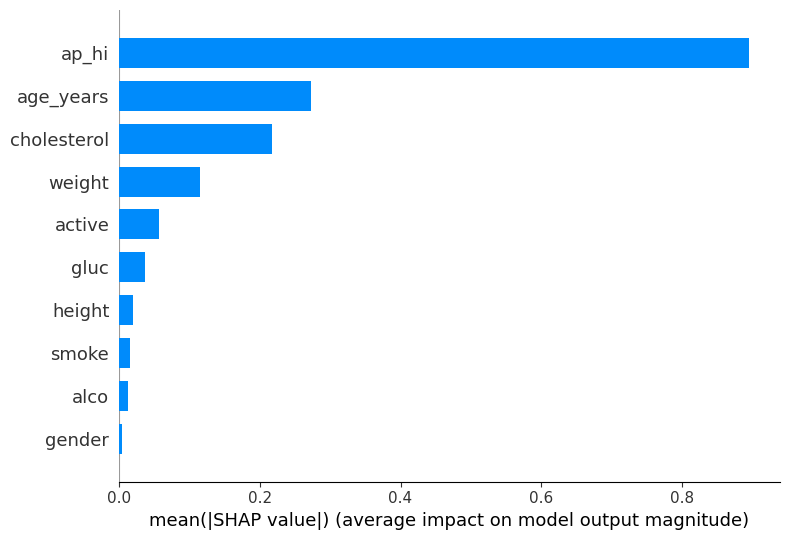

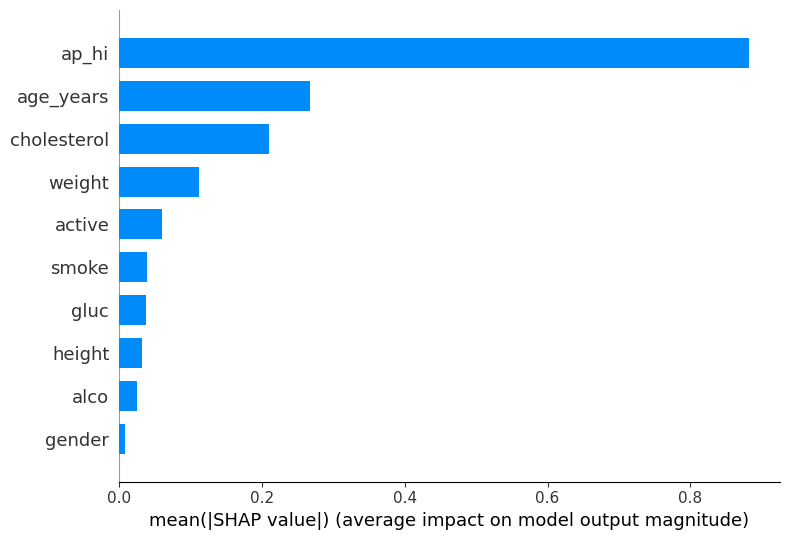

In [ ]:
shap.summary_plot(shap_values_female, X_test_female, plot_type="bar")
shap.summary_plot(shap_values_male, X_test_male, plot_type="bar")

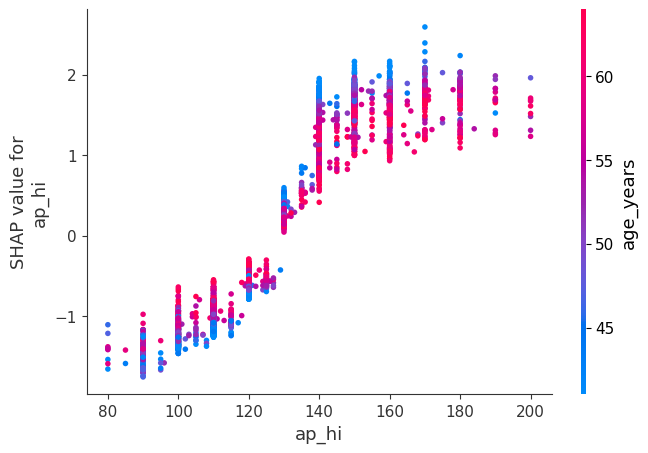

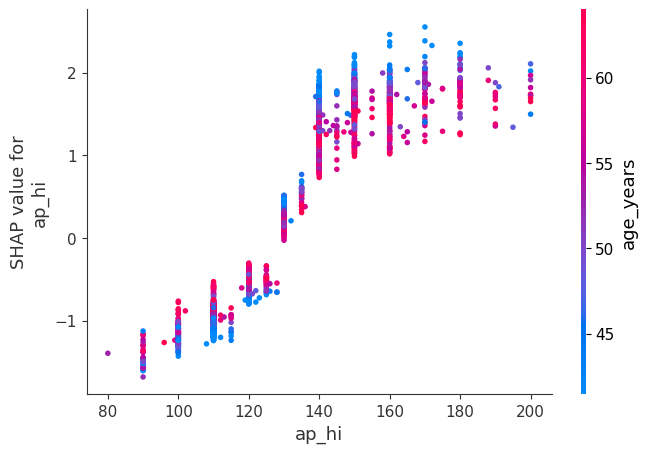

In [ ]:
shap.dependence_plot("ap_hi", shap_values_female, X_test_female)
shap.dependence_plot("ap_hi", shap_values_male, X_test_male)

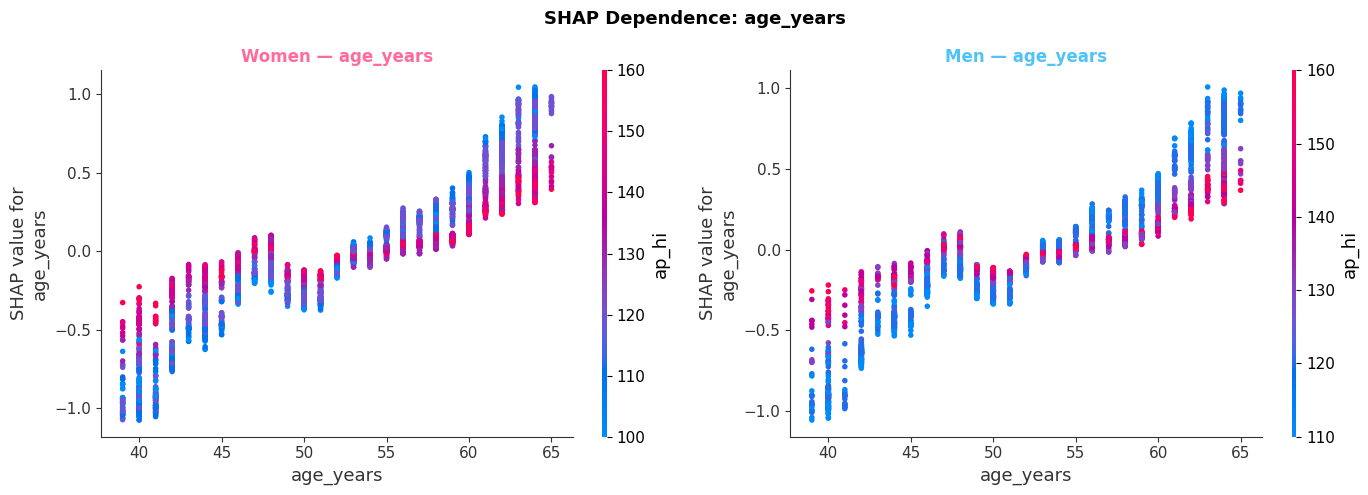

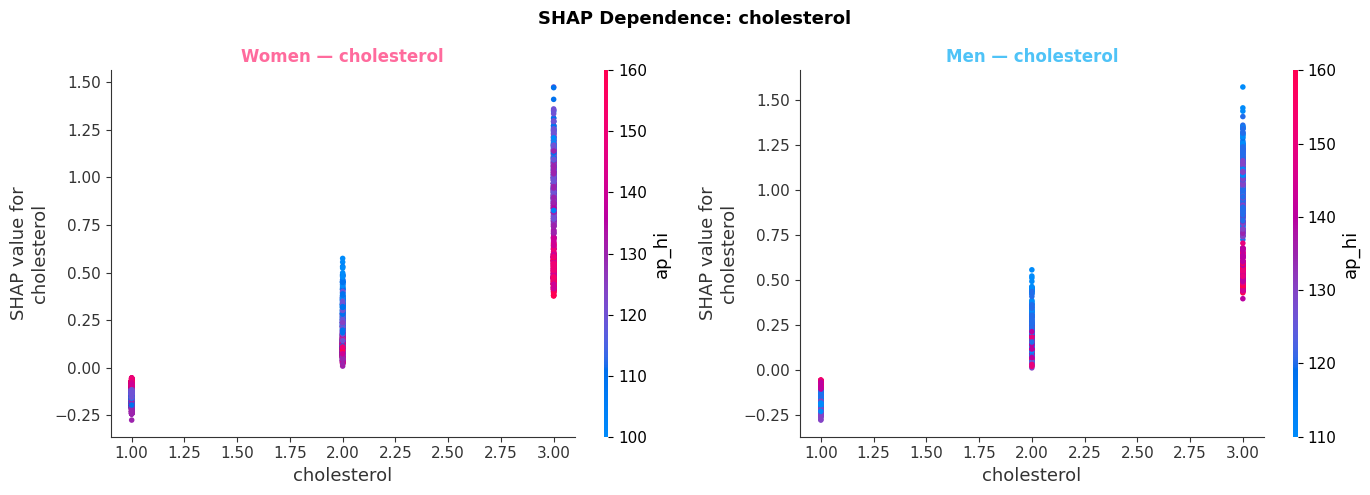

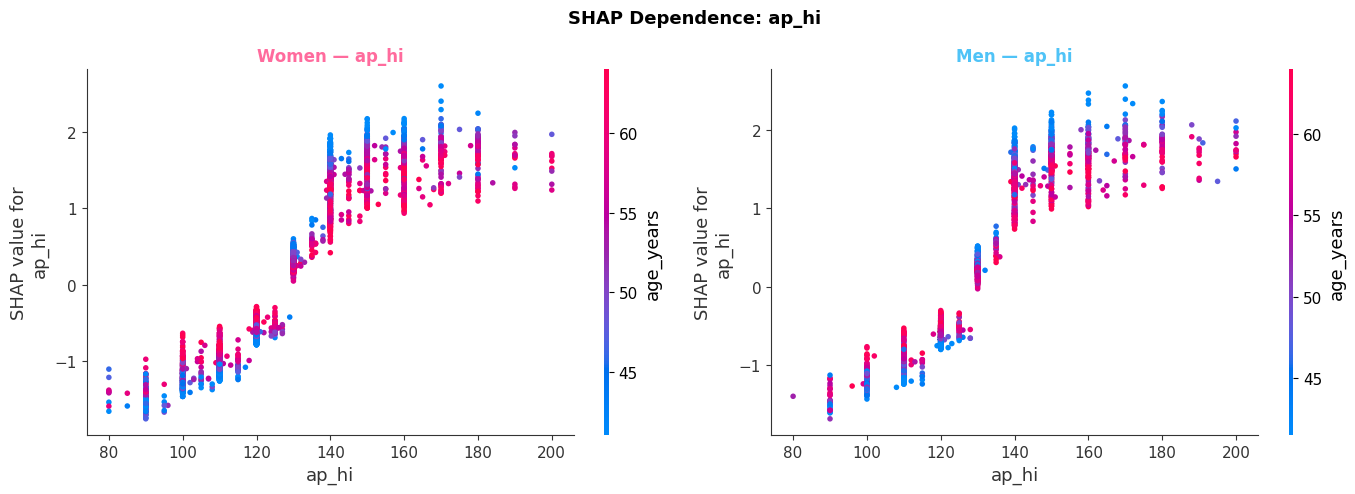

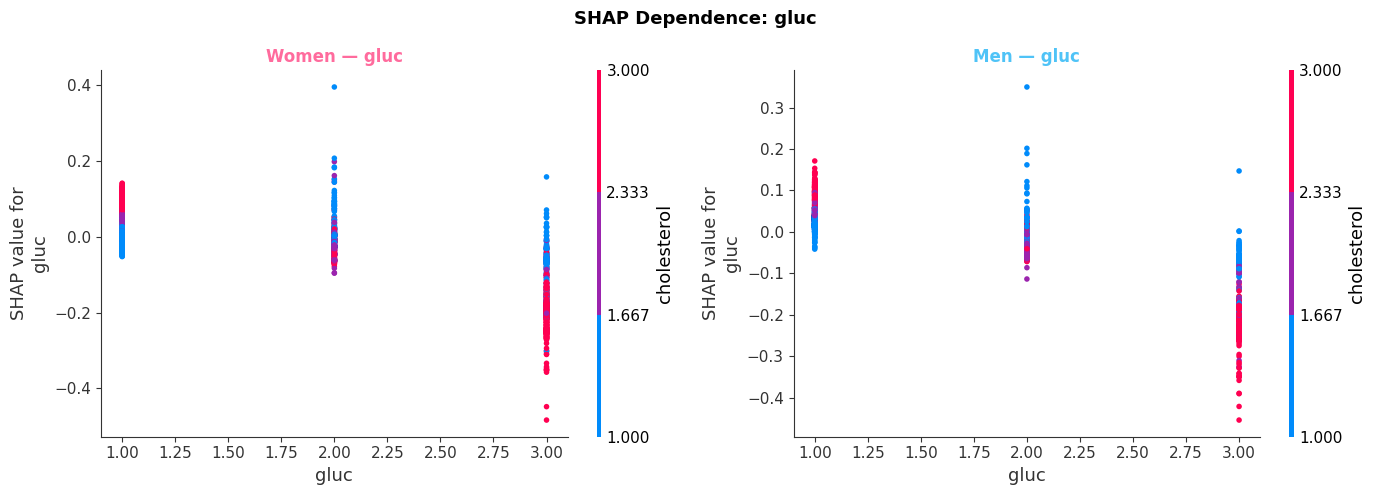

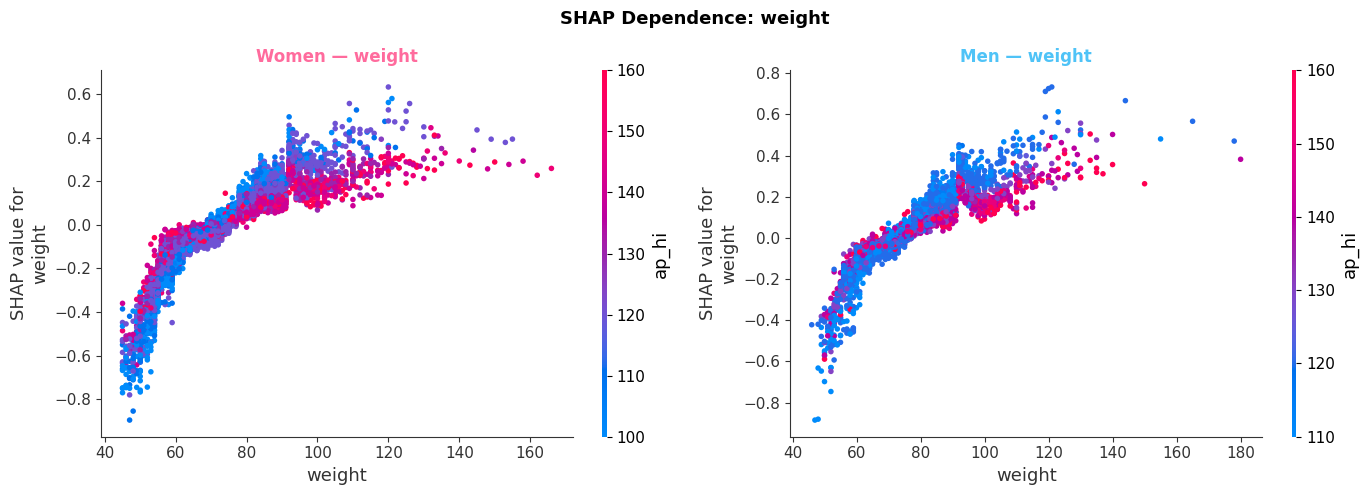

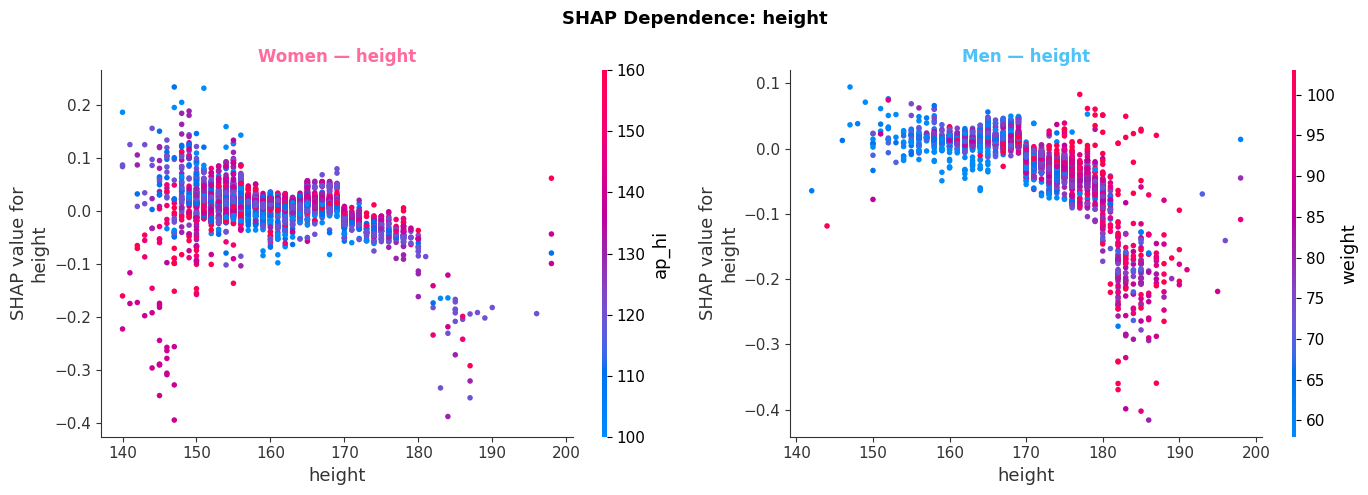

In [ ]:
# features = ["age_years", "cholesterol", "ap_hi", "gluc", "weight", "height"]

# for f in features:
#     shap.dependence_plot(f, shap_values_female, X_test_female)
#     shap.dependence_plot(f, shap_values_male, X_test_male)

    
features = ["age_years", "cholesterol", "ap_hi", "gluc", "weight", "height"]

for f in features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    shap.dependence_plot(f, shap_values_female, X_test_female, 
                         ax=axes[0], show=False)
    axes[0].set_title(f"Women — {f}", fontweight="bold", color="#ff6b9d")
    
    shap.dependence_plot(f, shap_values_male, X_test_male,
                         ax=axes[1], show=False)
    axes[1].set_title(f"Men — {f}", fontweight="bold", color="#4fc3f7")
    
    plt.suptitle(f"SHAP Dependence: {f}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"shap_dependence_{f}.png", dpi=150, bbox_inches="tight")
    plt.show()

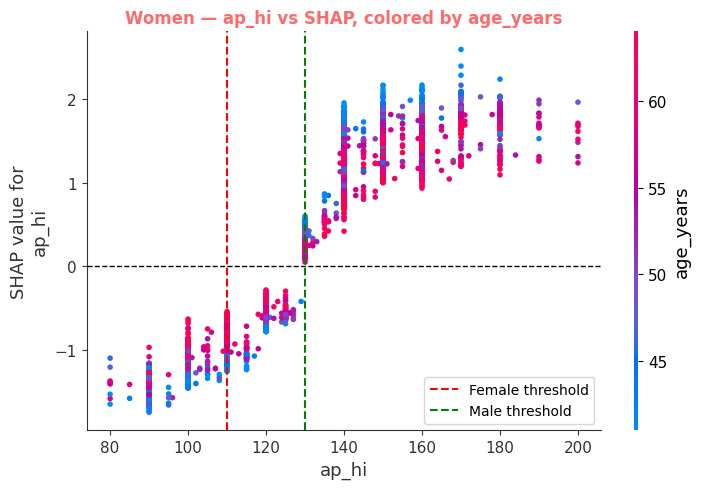

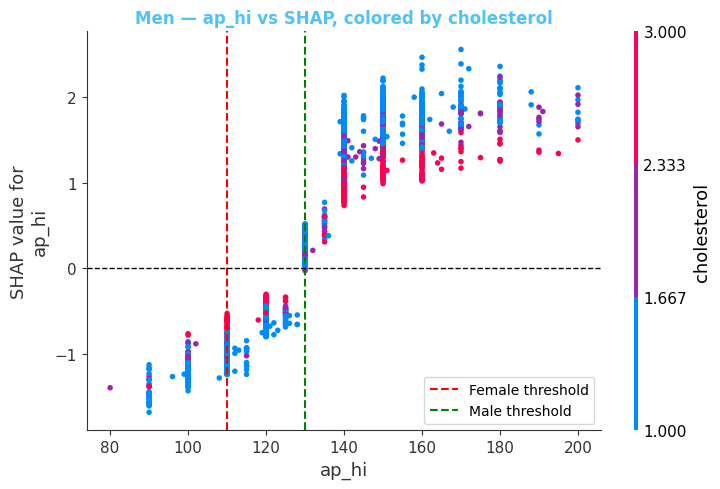

In [ ]:
shap.dependence_plot(
    "ap_hi", 
    shap_values_female, 
    X_test_female,
    interaction_index="age_years",
    show=False
)
plt.title("Women — ap_hi vs SHAP, colored by age_years", 
          fontweight="bold", color="#ff6b6b")
plt.axvline(x=110, color="red",   linestyle="--", linewidth=1.5, label="Female threshold")
plt.axvline(x=130, color="green", linestyle="--", linewidth=1.5, label="Male threshold")
plt.axhline(y=0,   color="black", linestyle="--", linewidth=1)
plt.legend()
plt.tight_layout()
plt.show()

shap.dependence_plot(
    "ap_hi",
    shap_values_male,
    X_test_male,
    interaction_index="cholesterol",
    show=False
)
plt.title("Men — ap_hi vs SHAP, colored by cholesterol",
          fontweight="bold", color="#4fc3f7")
plt.axvline(x=110, color="red",   linestyle="--", linewidth=1.5, label="Female threshold")
plt.axvline(x=130, color="green", linestyle="--", linewidth=1.5, label="Male threshold")
plt.axhline(y=0,   color="black", linestyle="--", linewidth=1)
plt.legend()
plt.tight_layout()
plt.show()

c:\Users\kavis\OneDrive\Desktop\Study Resources\Year 3\Diss\Code\Dissertation_ExplainableAI\.venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\kavis\OneDrive\Desktop\Study Resources\Year 3\Diss\Code\Dissertation_ExplainableAI\.venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will r

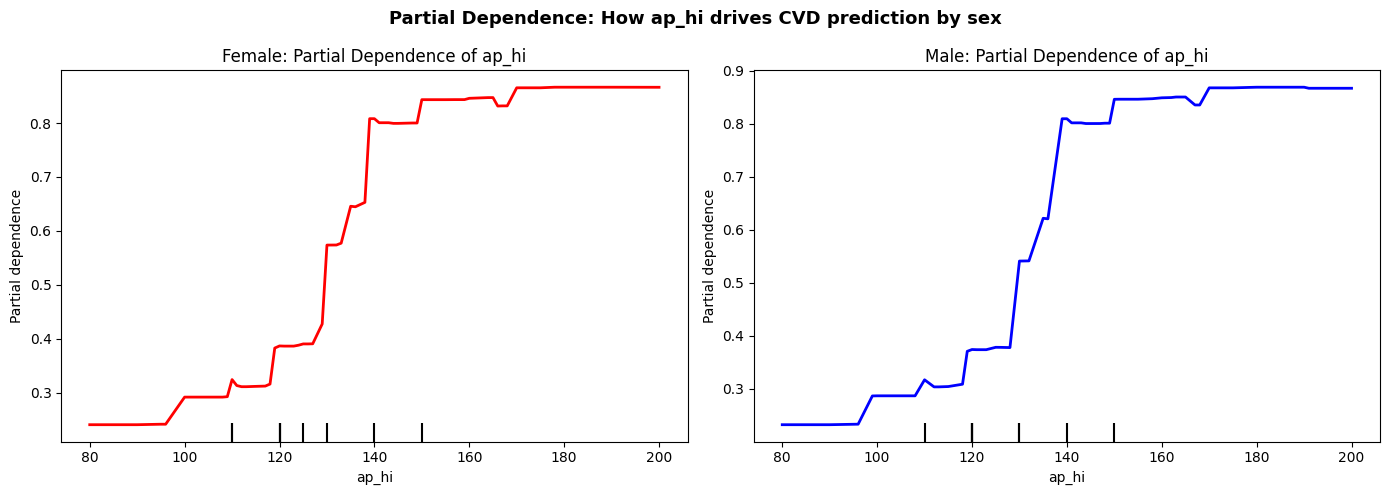

c:\Users\kavis\OneDrive\Desktop\Study Resources\Year 3\Diss\Code\Dissertation_ExplainableAI\.venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 9 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\kavis\OneDrive\Desktop\Study Resources\Year 3\Diss\Code\Dissertation_ExplainableAI\.venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 9 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will r

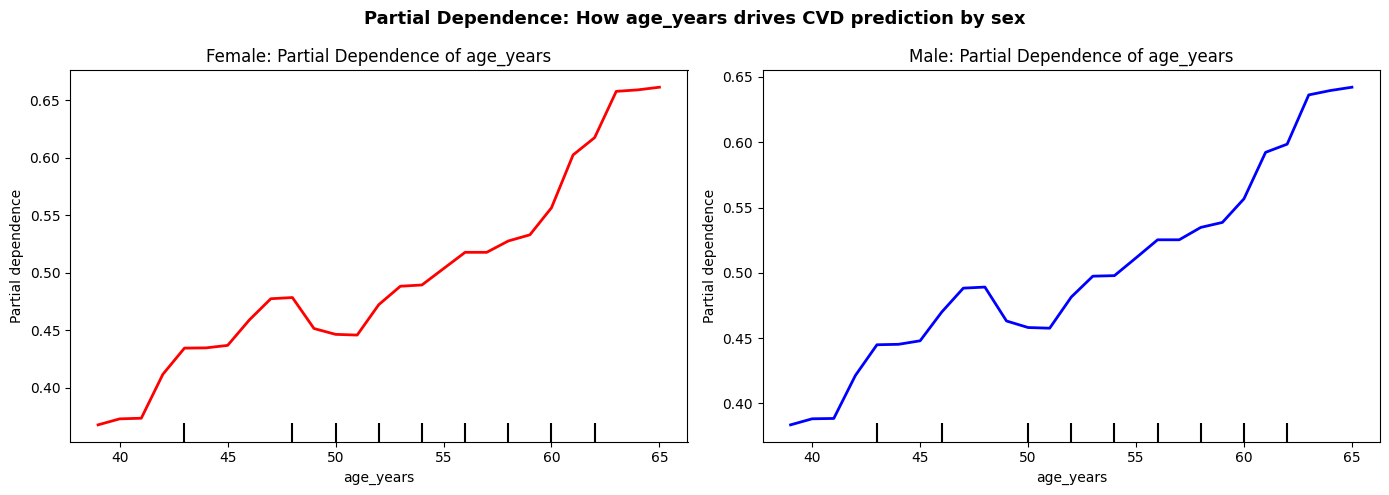

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Add or remove features from this list
features_to_plot = ["ap_hi", "age_years"]

clinical_refs = {
    "ap_hi": [
        {"x": 110, "color": "red",    "label": "Female risk threshold (Ji et al.)"},
        {"x": 130, "color": "green",  "label": "Male risk threshold (Ji et al.)"}
    ],
    "age_years": [
        {"x": 52,  "color": "orange", "label": "Peri-menopausal transition (Ji et al.)"}
    ]
}

for feature in features_to_plot:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax, X_data, color, title in [
        (axes[0], X_test_female, "red",  "Female"),
        (axes[1], X_test_male,   "blue", "Male")
    ]:
        PartialDependenceDisplay.from_estimator(
            model_baseline,
            X_data,
            features=[feature],
            ax=ax,
            line_kw={"color": color, "linewidth": 2}
        )
        
        if feature in clinical_refs:
            for ref in clinical_refs[feature]:
                ax.axvline(x=ref["x"], color=ref["color"],
                          linestyle='--', linewidth=1.5, label=ref["label"])
            ax.legend(fontsize=8)
        
        ax.set_title(f"{title}: Partial Dependence of {feature}")
        ax.grid(alpha=0.3)
    
    plt.suptitle(
        f"Partial Dependence: How {feature} drives CVD prediction by sex",
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(f"partial_dependence_{feature}.png", dpi=150)
    plt.show()

### The ap_hi dependence plot
- There is a steep rise at 130mmHg+ because that is how xgboost behaves. XGBoost is a tree-based model. It learns by finding split points — specific feature values where it divides patients into higher and lower risk groups. When it finds that 130mmHg is a strong split point, every patient below 130 gets routed one way and every patient above gets routed another.
This creates step-function behaviour rather than a smooth curve. The steep jump at 130mmHg means the model found that threshold to be the single most discriminative BP value in the training data.
- Because that's where the training data showed the strongest signal. At 130mmHg+ there were enough correctly labelled CVD cases (mostly men, given label bias) to create a reliable split. Below 130mmHg the signal was weak — partly because women with CVD at those levels were mislabelled as negative.



In [ ]:
import numpy as np
import pandas as pd

feature = "ap_hi"
bins = [0, 120, 130, 140, 150, 160, np.inf]
bin_labels = ["<120", "120-129", "130-139", "140-149", "150-159", "160+"]
high_risk_bins = ["140-149", "150-159", "160+"]

# ── Build female df with SHAP ─────────────────────────────────
df = X_test_female.copy().reset_index(drop=True)
feature_idx = X_test_female.columns.get_loc(feature)
df["shap_value"] = shap_values_female[:, feature_idx].astype(float)

df["feature_bin"] = pd.cut(
    df[feature], bins=bins, labels=bin_labels, right=False
)

# ── 10th percentile threshold per bin ────────────────────────
thresholds = df.groupby("feature_bin")["shap_value"].quantile(0.10).astype(float).to_dict()
df["bin_threshold"] = df["feature_bin"].astype(str).map(thresholds)

# ── Underresponse flags ───────────────────────────────────────
df["underresponse_flag"] = (
    df["shap_value"] <= df["bin_threshold"]
).astype(int)

df["underresponse_flag_highrisk"] = (
    df["feature_bin"].isin(high_risk_bins) &
    (df["shap_value"] <= df["bin_threshold"])
).astype(int)

# ── Add FN indicator ──────────────────────────────────────────
# Reset index on female mask to align with df
female_mask = test_df_baseline["gender"].values == 0

y_test_female = y_test_baseline[female_mask].reset_index(drop=True)
y_pred_female = model_baseline.predict(X_test_female)

df["true_label"] = y_test_female.values
df["predicted"]  = y_pred_female
df["is_fn"]      = ((df["true_label"] == 1) & (df["predicted"] == 0)).astype(int)

# ── Validation — does the flag capture FN women? ─────────────
flagged = df["underresponse_flag"] == 1
fn      = df["is_fn"] == 1

precision_flag = df[flagged]["is_fn"].mean()
recall_flag    = df[fn]["underresponse_flag"].mean()

print(f"Of flagged women    — % that are FN : {precision_flag:.3f}")
print(f"Of FN women         — % captured    : {recall_flag:.3f}")

# ── Per bin breakdown ─────────────────────────────────────────
print(f"\n{'Bin':<12} {'FN rate flagged':>18} {'FN rate unflagged':>20} {'N flagged':>12}")

for bin_label in bin_labels:
    bin_df            = df[df["feature_bin"] == bin_label]
    flagged_fn_rate   = bin_df[bin_df["underresponse_flag"] == 1]["is_fn"].mean()
    unflagged_fn_rate = bin_df[bin_df["underresponse_flag"] == 0]["is_fn"].mean()
    n_flagged         = (bin_df["underresponse_flag"] == 1).sum()
    print(f"{bin_label:<12} {flagged_fn_rate:>18.3f} {unflagged_fn_rate:>20.3f} {n_flagged:>12}")

Of flagged women    — % that are FN : 0.089
Of FN women         — % captured    : 0.060

Bin             FN rate flagged    FN rate unflagged    N flagged
<120                      0.118                0.185          186
120-129                   0.149                0.274          350
130-139                   0.043                0.053          116
140-149                   0.000                0.000          126
150-159                   0.000                0.000           54
160+                      0.000                0.000           58


In [ ]:
# df_male = X_test_male.copy()
# feature_idx = X_test_male.columns.get_loc(feature)
# df_male["shap_value"] = shap_values_male[:, feature_idx]

# df_male["feature_bin"] = pd.cut(
#     df_male[feature],
#     bins=[0, 120, 130, 140, 150, 160, np.inf],
#     labels=["<120", "120-129", "130-139", "140-149", "150-159", "160+"],
#     right=False
# )

# male_thresholds = df_male.groupby("feature_bin")["shap_value"].quantile(0.10)
# male_thresholds = male_thresholds.astype(float).to_dict()

# print("Male thresholds:")
# print(male_thresholds)
# print("\nFemale thresholds:")
# print(thresholds)

Now age bins

In [ ]:
# ── ap_hi ──────────────────────────────────────────────────────────────────

feature_aphi = "ap_hi"

df_f_aphi = X_test_female.copy()
feature_idx = X_test_female.columns.get_loc(feature_aphi)
df_f_aphi["shap_value"] = shap_values_female[:, feature_idx]
df_f_aphi["feature_bin"] = pd.cut(
    df_f_aphi[feature_aphi],
    bins=[0, 120, 130, 140, 150, 160, np.inf],
    labels=["<120", "120-129", "130-139", "140-149", "150-159", "160+"],
    right=False
)
female_thresholds_aphi = df_f_aphi.groupby("feature_bin")["shap_value"].quantile(0.10).astype(float).to_dict()

df_m_aphi = X_test_male.copy()
df_m_aphi["shap_value"] = shap_values_male[:, feature_idx]
df_m_aphi["feature_bin"] = pd.cut(
    df_m_aphi[feature_aphi],
    bins=[0, 120, 130, 140, 150, 160, np.inf],
    labels=["<120", "120-129", "130-139", "140-149", "150-159", "160+"],
    right=False
)
male_thresholds_aphi = df_m_aphi.groupby("feature_bin")["shap_value"].quantile(0.10).astype(float).to_dict()

print("=== ap_hi ===")
print("Female:", female_thresholds_aphi)
print("Male:  ", male_thresholds_aphi)

# ── age_years ───────────────────────────────────────────────────────────────
# Clinical bins: women's CVD risk accelerates post-menopause (~50+)

feature_age = "age_years"

df_f_age = X_test_female.copy()
feature_idx_age = X_test_female.columns.get_loc(feature_age)
df_f_age["shap_value"] = shap_values_female[:, feature_idx_age]
df_f_age["feature_bin"] = pd.cut(
    df_f_age[feature_age],
    bins=[0, 40, 45, 50, 55, 60, np.inf],
    labels=["<40", "40-44", "45-49", "50-54", "55-59", "60+"],
    right=False
)
female_thresholds_age = df_f_age.groupby("feature_bin")["shap_value"].quantile(0.10).astype(float).to_dict()

df_m_age = X_test_male.copy()
df_m_age["shap_value"] = shap_values_male[:, feature_idx_age]
df_m_age["feature_bin"] = pd.cut(
    df_m_age[feature_age],
    bins=[0, 40, 45, 50, 55, 60, np.inf],
    labels=["<40", "40-44", "45-49", "50-54", "55-59", "60+"],
    right=False
)
male_thresholds_age = df_m_age.groupby("feature_bin")["shap_value"].quantile(0.10).astype(float).to_dict()

print("\n=== age_years ===")
print("Female:", female_thresholds_age)
print("Male:  ", male_thresholds_age)

df_thresholds = pd.DataFrame({
    "female_ap": female_thresholds_aphi,
    "make_ap":male_thresholds_aphi
})

df_thresholds.to_csv("aphi_thresholds.csv", index = False)



=== ap_hi ===
Female: {'<120': -1.3660076975822448, '120-129': -0.7040361404418946, '130-139': 0.19836047887802125, '140-149': 0.8990057468414306, '150-159': 1.2173775434494019, '160+': 1.244414007663727}
Male:   {'<120': -1.2398578882217408, '120-129': -0.7227269053459168, '130-139': 0.13934744745492936, '140-149': 0.9688667058944702, '150-159': 1.310826063156128, '160+': 1.3187048077583314}

=== age_years ===
Female: {'<40': -1.036835289001465, '40-44': -0.969389408826828, '45-49': -0.29590020179748533, '50-54': -0.30397269129753113, '55-59': 0.030605357140302658, '60+': 0.16372447162866594}
Male:   {'<40': -1.0040327072143556, '40-44': -0.9193822503089905, '45-49': -0.27216725051403046, '50-54': -0.2863025337457657, '55-59': 0.03587344065308571, '60+': 0.15816221982240677}
